# Iris Flower Classification

This notebook builds a machine learning model that classifies iris flowers as `Iris-setosa`, `Iris-versicolor`, or `Iris-virginica` using sepal and petal measurements.


## 1. Import Libraries


In [1]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

sns.set_theme(style="whitegrid")

TASK_DIR_NAME = "DhruvGajjar_Task-1"
PROJECT_ROOT = None
search_roots = [Path.cwd(), *Path.cwd().parents]

for candidate in search_roots:
    possible_task_dirs = [candidate, candidate / TASK_DIR_NAME]
    for possible_task_dir in possible_task_dirs:
        if (possible_task_dir / "dataset" / "Iris.csv").exists():
            PROJECT_ROOT = possible_task_dir
            break
    if PROJECT_ROOT is not None:
        break

if PROJECT_ROOT is None:
    raise FileNotFoundError("Dataset not found. Open the notebook from the repo root or DhruvGajjar_Task-1 folder.")

DATA_PATH = PROJECT_ROOT / "dataset" / "Iris.csv"
IMAGES_DIR = PROJECT_ROOT / "images"
MODELS_DIR = PROJECT_ROOT / "models"

IMAGES_DIR.mkdir(exist_ok=True)
MODELS_DIR.mkdir(exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Dataset path: {DATA_PATH}")
print("Libraries imported successfully.")


Libraries imported successfully.


## 2. Load Dataset


In [2]:
df = pd.read_csv(DATA_PATH)
print("Dataset loaded successfully.")
df.head()

Dataset loaded successfully.


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


## 3. Explore Dataset


In [3]:
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
df.info()

Rows: 150
Columns: 6
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 7.2 KB


In [4]:
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


In [5]:
missing_values = df.isnull().sum()
duplicate_rows = df.duplicated().sum()

print("Missing values by column:")
print(missing_values)
print(f"\nDuplicate rows: {duplicate_rows}")


Missing values by column:
Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

Duplicate rows: 0


In [6]:
df["Species"].value_counts()


Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

## 4. Visualize Dataset


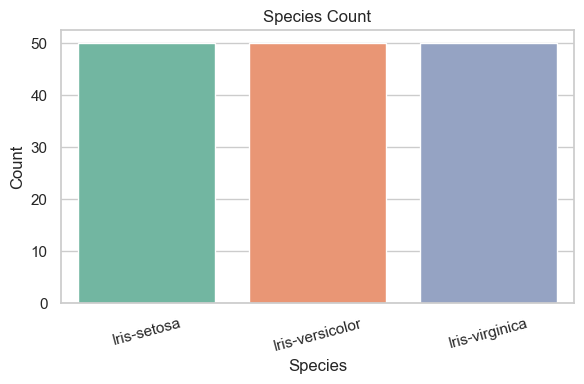

In [7]:
plt.figure(figsize=(6, 4))
sns.countplot(x="Species", data=df, palette="Set2", hue="Species", legend=False)
plt.title("Species Count")
plt.xlabel("Species")
plt.ylabel("Count")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(IMAGES_DIR / "species_count.png", dpi=300, bbox_inches="tight")
plt.show()


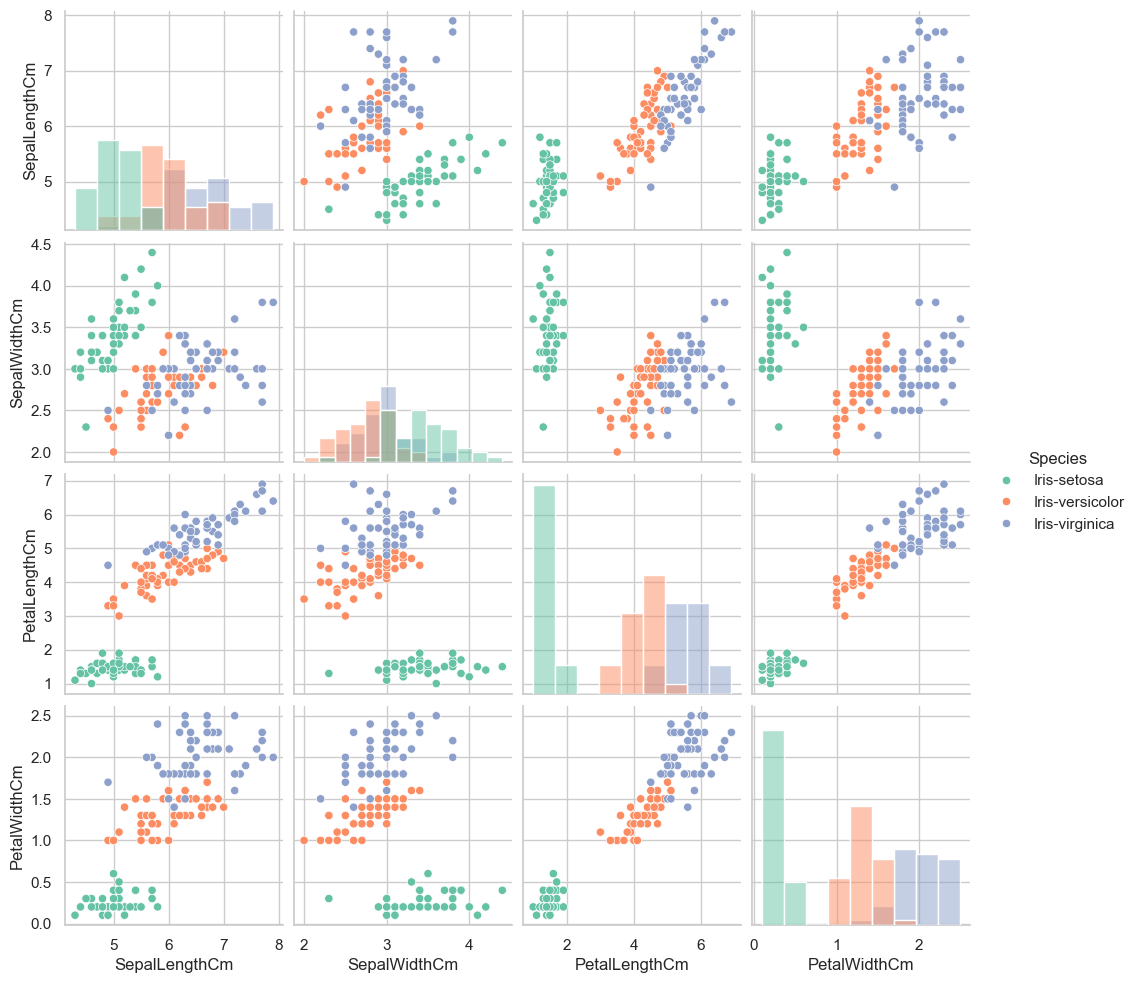

In [8]:
feature_columns = ["SepalLengthCm", "SepalWidthCm", "PetalLengthCm", "PetalWidthCm"]

sns.pairplot(df, vars=feature_columns, hue="Species", palette="Set2", diag_kind="hist")
plt.show()


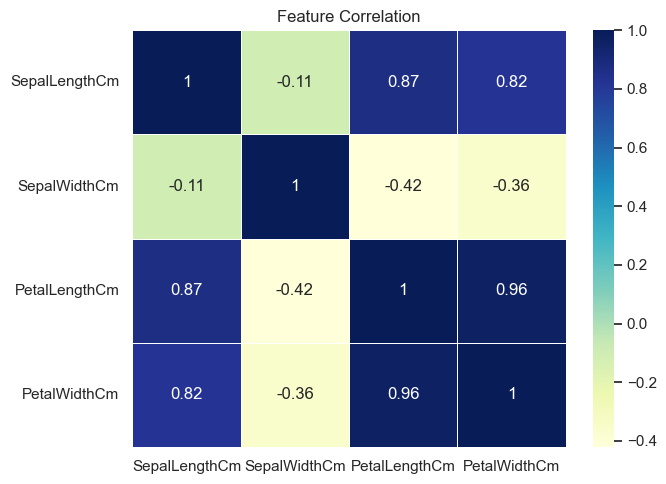

In [9]:
plt.figure(figsize=(7, 5))
sns.heatmap(df[feature_columns].corr(), annot=True, cmap="YlGnBu", linewidths=0.5)
plt.title("Feature Correlation")
plt.tight_layout()
plt.show()


## 5. Prepare Data


In [10]:
X = df[feature_columns]
y = df["Species"]

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

class_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
class_mapping


{'Iris-setosa': np.int64(0),
 'Iris-versicolor': np.int64(1),
 'Iris-virginica': np.int64(2)}

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded,
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")


Training samples: 120
Testing samples: 30


## 6. Train Model


In [12]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print("Model trained successfully.")


Model trained successfully.


## 7. Evaluate Model


In [13]:
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.2%}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))


Accuracy: 90.00%

Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.82      0.90      0.86        10
 Iris-virginica       0.89      0.80      0.84        10

       accuracy                           0.90        30
      macro avg       0.90      0.90      0.90        30
   weighted avg       0.90      0.90      0.90        30



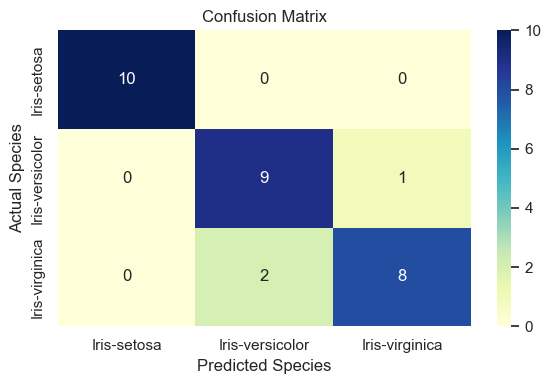

In [14]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="YlGnBu",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_,
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Species")
plt.ylabel("Actual Species")
plt.tight_layout()
plt.savefig(IMAGES_DIR / "confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()


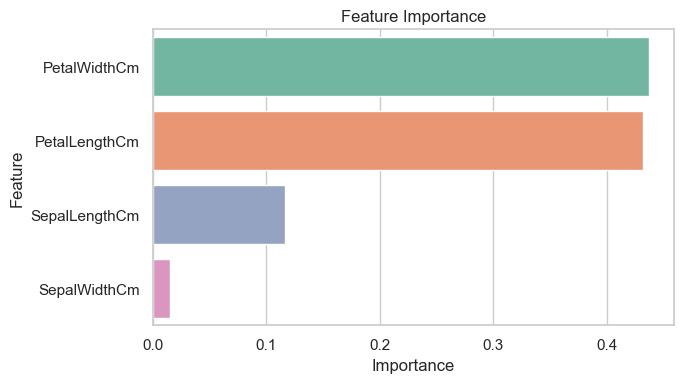

,Feature,Importance
3,PetalWidthCm,0.437185
2,PetalLengthCm,0.431466
0,SepalLengthCm,0.116349
1,SepalWidthCm,0.015000


In [15]:
feature_importance = pd.DataFrame({
    "Feature": feature_columns,
    "Importance": model.feature_importances_,
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(7, 4))
sns.barplot(data=feature_importance, x="Importance", y="Feature", palette="Set2", hue="Feature", legend=False)
plt.title("Feature Importance")
plt.tight_layout()
plt.show()

feature_importance


## 8. Test a Sample Prediction


In [16]:
sample = pd.DataFrame(
    [[5.1, 3.5, 1.4, 0.2]],
    columns=feature_columns,
)

prediction = model.predict(sample)
predicted_species = label_encoder.inverse_transform(prediction)[0]
print(f"Predicted species: {predicted_species}")


Predicted species: Iris-setosa


## 9. Save Model


In [17]:
model_bundle = {
    "model": model,
    "label_encoder": label_encoder,
    "feature_columns": feature_columns,
}

model_path = MODELS_DIR / "iris_random_forest.pkl"
joblib.dump(model_bundle, model_path)

print(f"Model saved to {model_path}")


Model saved to models\iris_random_forest.pkl


## Conclusion

The Random Forest classifier successfully classifies iris flowers using four measurement features. Petal measurements are usually the most useful predictors for this dataset, and the saved model can be reused for future predictions.
